In [1]:
%pdb off

Automatic pdb calling has been turned OFF


In [1]:
%load_ext autoreload
%autoreload 2

import pipeline
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import count
import time
import pickle
from sklearn.manifold import TSNE
import shutil
import sys
import itertools
from collections import defaultdict
import geopandas as gpd
from tqdm.auto import tqdm
from libpysal.weights import Queen
import esda
import glob, os, re
from scipy.stats import ks_2samp
import math
from haversine import haversine, Unit
from scipy.stats import wasserstein_distance

import plotly.io as pio
pio.renderers.default = "notebook"

seed = 21
vers = 'agg'
aggtype = 'undir'
agg = False
weight = 'cov'

if vers == "6":
    fpath = Path('data/undir_trials/6h/thresholded_networks/0_network.txt')
    save_dir = Path(f'data/undir_trials/6h/tests/seed{seed}')
    data = Path('data/undir_trials/depnet_undirected.gz')
elif vers == '24':
    fpath = Path('data/undir_trials/24h/0_network_24h.txt')
    save_dir = Path(f'data/undir_trials/24h/tests/seed{seed}')
    data = Path('data/undir_trials/24h/depnet_undirected_24h.gz')
elif vers == 'agg':
    if aggtype == 'undir':
        fpath = Path('data/agg/agg_network_24h_undir.pkl')
        save_dir = Path(f'data/agg/undir_dep/tests/seed{seed}')
    elif aggtype == 'dir':
        fpath = Path('data/agg/agg_network_24h_dir.pkl')
        save_dir = Path(f'data/agg/dir_dep/tests/seed{seed}')
    agg = True
    weight = 'num_occ'
else:
    print("Invalid version.")

save_dir.mkdir(parents=True, exist_ok=True)
if agg:
    print(f"Version: {vers} ({aggtype}ected type)")
else:
    print(f"Version: {vers}")
print(f'Seed: {seed}')

Version: agg (undirected type)
Seed: 21


In [ ]:
# blank canvas for checking file structure if needed

### Thresholding and Building Network(s)

In [ ]:
# --- dependency distribution ---

# reading in + dealing with missing values
df = pd.read_csv(data)
df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
df = df.dropna(subset=['DEP'])

# sampling for performance
plot_data = df['DEP'].sample(100000)
print(plot_data.describe())

sns.displot(plot_data, bins=30, kde=True, stat='probability', log_scale=True)
plt.margins(x=0)

# --- num removed vs binned values ---

dep_nonzero = df.loc[df['DEP'] > 0, 'DEP'].sort_values().values
total_edges = len(df)
zero_edges = total_edges - len(dep_nonzero)

print(f"Total edges: {total_edges}")
print(f"Zero-DEP edges: {zero_edges}")
print(f"Nonzero DEP range: [{dep_nonzero.min():.2e}, {dep_nonzero.max():.2e}]")

# log-spaced bins across the nonzero DEP range
bins = np.logspace(np.log10(dep_nonzero.min()), np.log10(dep_nonzero.max()), 200)

# for each threshold, edges retained = nonzero edges with DEP >= threshold
edges_retained = len(dep_nonzero) - np.searchsorted(dep_nonzero, bins, side='left')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bins, edges_retained)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('DEP threshold')
ax.set_ylabel('Number of edges retained')
ax.set_title('Edges retained vs DEP threshold')

ax.axhline(y=1_000_000, color='r', linestyle='--', label='1M edges')
ax.axhline(y=10_000, color='orange', linestyle='--', label='10k edges')
ax.legend()
plt.show()

# find approximate thresholds
vals = []
for target, label in [(1_000_000, 'DEP_low (~1M)'), (10_000, 'DEP_high (~10k)')]:
    idx = np.argmin(np.abs(edges_retained - target))
    vals.append(bins[idx])
    print(f"{label}: DEP ≈ {bins[idx]:.6e}, edges retained = {edges_retained[idx]}")

DEP_low = vals[0]
DEP_high = vals[1]

In [ ]:
all = 0

# reloading df if needed
if 'df' not in globals():
    df = pd.read_csv(data)
    df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
    df = df.dropna(subset=['DEP'])

if all:
    # filtering
    DEP_range = df[df['DEP'].between(DEP_low, DEP_high)]
    # calculating thresholds with bounded range
    quantiles = np.quantile(DEP_range['DEP'], [0.25, 0.5, 0.75])
    thresholds = np.concatenate([[DEP_low], quantiles, [DEP_high]])

    # creating networks with original uncapped df
    for i, threshold in zip(count(0, 0.25), thresholds):
        # filter
        thresholded_df = df[df['DEP'] >= threshold]
        
        # save df directly
        filepath = f'data/undir_trials/thresholded_networks/{i}_network.txt'
        thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
        
        print(f"Saved {filepath} with {len(thresholded_df)} edges")
else:
    thresholded_df = df[df['DEP'] >= DEP_low]
    filepath = f'data/undir_trials/24h/network.txt'
    thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
    print(f"Saved {filepath} with {len(thresholded_df)} edges")

Saved data/undir_trials/24h/network.txt with 991526 edges


### Test Run Template

In [7]:
# --- new split if needed ---

print(f"Using seed: {seed}")
print(f"Version check: {vers}")

split_path = save_dir / f"split_{seed}.pkl"
train_path = save_dir / f"train_{seed}.txt"

if split_path.is_file():
    print(f"Split already exists for seed: {seed}. Exiting...")
    sys.exit()

G, train_neg, test_pos, test_neg = pipeline.prepare_data(
    fpath, frac=.25, seed=seed, weight=weight, agg=agg, meta=True,
    trainfile=train_path)

save_dir.mkdir(parents=True, exist_ok=True)
with open(split_path, 'wb') as f:
    pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
print(f"Saved split → {split_path}")

Using seed: 21
Version check: agg


Sampling non-edges (fast):   0%|          | 0/1289541 [00:00<?, ?edge/s]

Sampling non-edges (fast):   0%|          | 0/3903472 [00:00<?, ?edge/s]

Wrote training graph: 15025 nodes, 3929892 edges
Saved split → data\agg\tests\seed21\split_21.pkl


In [ ]:
# set parameters
p, q, dim = 4, 0.25, 192
weighted = True
cat_threshold = 20

In [ ]:
# --- single test ---

print(f"Using seed: {seed}")
print(f"Version check: {vers} (agg={agg})")

#file_path = save_dir / f"split_{seed}.pkl"
file_path = save_dir / f"old_sampler/split_{seed}.pkl"
with open(file_path, 'rb') as f:
            G, train_neg, test_pos, test_neg = pickle.load(f)

feats = ['emb']

auc, _ = pipeline.run_pipeline(save_dir / f"train_{seed}.txt", 
                                train_neg, test_pos, test_neg, seed=seed,
                                p=p, q=q, dim=192, workers=6, weighted=weighted,
                                features=feats, cat_threshold=cat_threshold, G=G,
                                agg=agg)

feats_id = '_'.join(feats) if isinstance(feats, list) else feats
with open(save_dir / 'new_code_old_seed.txt', 'w') as f:
        f.write(str(auc))
        print('Score saved.')
# with open(save_dir / f'score_seed{seed}-p{p}-q{q}-dim{dim}-w{weighted}-feats_{feats_id}-ct{cat_threshold}.txt', 'w') as f:
#         f.write(str(auc))
#         print('Score saved.')

In [ ]:
# --- comprehensive test ---

print(f"Using seed: {seed}")
print(f"Version check: {vers} (agg={agg})")

file_path = save_dir / f"split_{seed}.pkl"
with open(file_path, 'rb') as f:
            G, train_neg, test_pos, test_neg = pickle.load(f)
            
feats_list = [
        ['emb', 'geo'],
        ['emb', 'comm'],
        ['emb', 'comm', 'time'],
        ['emb', 'comm', 'time', 'income'],
        ['geo'],
        ['comm'],
        ['time'],
        ['income'],
        ['comm', 'time', 'income'],
        ['comm', 'time'],
        ['comm', 'income'],
        ['time', 'income']
]

for f in feats_list:
        print(f'NOW TESTING: {f}')
        feats = f
        auc, _ = pipeline.run_pipeline(save_dir / f"train_{seed}.txt", 
                                        train_neg, test_pos, test_neg, seed=seed,
                                        p=p, q=q, dim=192, workers=6, weighted=weighted,
                                        features=feats, cat_threshold=cat_threshold, G=G,
                                        agg=agg)

        feats_id = '_'.join(feats) if isinstance(feats, list) else feats
        with open(save_dir / f'score_seed{seed}-p{p}-q{q}-dim{dim}-w{weighted}-feats_{feats_id}-ct{cat_threshold}.txt', 'w') as f:
                f.write(str(auc))
                print('Score saved.')

Using seed: 21
Version check: agg (agg=True)
NOW TESTING: ['emb', 'geo']


  0%|          | 0/150160 [00:00<?, ?it/s]

Took 00:02:04.38 to generate walks


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Took 00:00:40.48 to train embeddings
Embeddings generated: 15016 nodes, dim=192
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
Training matrix: 7854394 samples x 193 features
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
[emb+geo (hadamard)]  AUC = 0.7168
Score saved.
NOW TESTING: ['emb', 'comm']


...

Took 00:00:42.94 to train embeddings
Embeddings generated: 15016 nodes, dim=192
Running Infomap...
Done.
Assigned 3 communities
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
Training matrix: 7854394 samples x 194 features
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
[emb+comm+time (hadamard)]  AUC = 0.7159
Score saved.
NOW TESTING: ['emb', 'comm', 'time', 'income']


  0%|          | 0/150160 [00:00<?, ?it/s]

Took 00:03:36.44 to generate walks


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Took 00:00:44.61 to train embeddings
Embeddings generated: 15016 nodes, dim=192
Running Infomap...
Done.
Assigned 3 communities
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
Training matrix: 7854394 samples x 195 features
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
[emb+comm+time+income (hadamard)]  AUC = 0.7415
Score saved.
NOW TESTING: ['geo']
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
Training matrix: 7858855 samples x 1 features
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
[geo]  AUC = 0.5059
Score saved.
NOW TESTING: ['comm']
Running Infomap...
Done.


### Distance-Controlled Negative Edge Sampling

Version: agg (undirected type)


Sampling non-edges (fast):   0%|          | 0/7512 [00:00<?, ?edge/s]

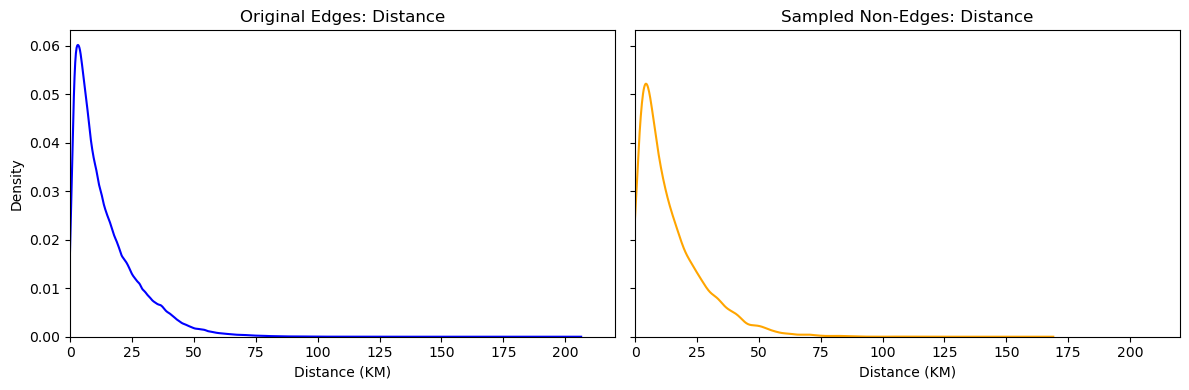

Wasserstein Distance: 0.0914


In [5]:
# Plots/Verification

from pipeline import distribution_finder, sample_non_edges_dist_controlled, sample_non_edges_agg_stratified, load
if agg:
    print(f"Version: {vers} ({aggtype}ected type)")
else:
    print(f"Version: {vers}")

# Generate the sample 
if agg == False:
    G = load('data/undir_trials/thresholded_networks/0_network.txt')
    distrs, sets = distribution_finder(G, bins=50)
    dist_distr = distrs[0]
    sample = sample_non_edges_dist_controlled(G, dist_distr, len(list(G.nodes())) // 2)
    original_distances = list(nx.get_edge_attributes(G, 'DIST_KM').values())
else:
    with open(fpath, 'rb') as f:
        G = pickle.load(f)
    distrs, sets = distribution_finder(G, bins=50)
    dist_distr = distrs[0]
    sample = sample_non_edges_dist_controlled(G, dist_distr, len(list(G.nodes())) // 2)
    #sample = sample_non_edges_agg_stratified(G, len(list(G.nodes())) // 2)
    original_distances = [d for d in nx.get_edge_attributes(G, 'DIST_KM').values() 
                      if d is not None and not math.isnan(d)]

locs = []
for u, v in sample:
    lat_u, lon_u = G.nodes[u]['latitude'], G.nodes[u]['longitude']
    lat_v, lon_v = G.nodes[v]['latitude'], G.nodes[v]['longitude']
    locs.append((lat_u, lon_u, lat_v, lon_v))

sampled_distances = [haversine((lat1, lon1), (lat2, lon2)) for (lat1, lon1, lat2, lon2) in locs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
pd.Series(original_distances).plot.kde(bw_method='scott', ax=axes[0], title='Original Edges: Distance', color='blue')
pd.Series(sampled_distances).plot.kde(bw_method='scott', ax=axes[1], title='Sampled Non-Edges: Distance', color='orange')
axes[0].set_xlabel('Distance (KM)')
axes[1].set_xlabel('Distance (KM)')
axes[0].set_xlim(left=0)
axes[1].set_ylim(bottom=0)
plt.tight_layout()
#plt.savefig(r'data\undir_trials\imgs\distance_distr_comp.png')
plt.show()

# wasserstein distance
print(f'Wasserstein Distance: {wasserstein_distance(original_distances, sampled_distances):.4f}')

In [ ]:
# Re-running pipeline

# --- prep ---
fpath = Path(r'data/undir_trials/thresholded_networks/0_network.txt')
G, train_neg, test_pos, test_neg = pipeline.prepare_data(fpath)

# --- metadata only ---
auc_geo, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo'])
auc_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['cat'])
auc_vis, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['visits'])
auc_geo_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo', 'cat'])
auc_all_metadata, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo', 'cat', 'visits'])

# --- embeddings only ---
auc_emb, emb_map = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb'])

# --- embeddings + metadata ---
auc_emb_geo, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo'], embedding_map=emb_map)
auc_emb_geo_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo', 'cat'], embedding_map=emb_map)
auc_all, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo', 'cat', 'visits'], embedding_map=emb_map)

# --- results table ---
results = [
    (['geo'],                          auc_geo),
    (['cat'],                          auc_cat),
    (['visits'],                       auc_vis),
    (['geo', 'cat'],                   auc_geo_cat),
    (['geo', 'cat', 'visits'],         auc_all_metadata),
    (['emb'],                          auc_emb),
    (['emb', 'geo'],                   auc_emb_geo),
    (['emb', 'geo', 'cat'],            auc_emb_geo_cat),
    (['emb', 'geo', 'cat', 'visits'],  auc_all),
]

df_results = pd.DataFrame(results, columns=['Features', 'AUC'])
df_results['Features'] = df_results['Features'].apply(lambda x: ' + '.join(x))
df_results['AUC'] = df_results['AUC'].round(4)

# flag embedding inclusion
df_results['Includes_Emb'] = df_results['Features'].str.contains('emb').map({True: 'with_emb', False: 'without_emb'})

In [ ]:
# AUC bar plot color-coded by embedding inclusion
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='AUC', y='Features', hue='Includes_Emb', dodge=False, palette={'with_emb':'tab:blue','without_emb':'tab:green'})
plt.title('AUC Scores by Feature Set (Distance-Controlled Negative Sampling)')
plt.xlabel('AUC')
plt.ylabel('Feature Set')
plt.xlim(left=0.5, right=1)
for i, value in enumerate(df_results['AUC']):
    plt.text(value + 0.001, i, f"{value:.4f}", va='center')
plt.legend(title='Includes Embedding')
plt.tight_layout()
plt.savefig('data/undir_trials/imgs/auc_by_feature_barplot.png')
plt.show()

### Sequential Hyperparameter Sweep

In [ ]:
# Sequential Hyperparameter Sweep: p → q → dim

# Saves the split to disk at the start so it survives kernel restarts.

sweep_dir = Path('data/undir_trials/hparam_sweep')
sweep_dir.mkdir(parents=True, exist_ok=True)

# Persist the split so it can be reloaded without re-running prepare_data
with open(sweep_dir / 'sweep_split.pkl', 'wb') as f:
    pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
print(f"Split saved → {sweep_dir / 'sweep_split.pkl'}")

FPATH   = 'train.txt'
WORKERS = 8
MODE    = 'PreComp'   # matches the baseline cell

# Walk params that match the baseline defaults in run_pipeline
WALK_KWARGS = dict(num_walks=10, walk_length=80, window_size=10)

P_VALUES   = [0.25, 0.50, 1, 2, 4]
Q_VALUES   = [0.25, 0.50, 1, 2, 4]
DIM_VALUES = [64, 96, 160, 192]

def run_phase(param_name, param_values, fixed):
    fixed_str = ', '.join(f"{k}={v}" for k, v in fixed.items())
    print(f"\n{'='*60}")
    print(f"PHASE: sweeping {param_name}  |  fixed: {fixed_str}")
    print(f"  values: {param_values}")
    print(f"{'='*60}")

    rows = []
    for val in param_values:
        kw = {**fixed, param_name: val}
        print(f"\n  [{param_name}={val}] starting ...", flush=True)
        t0 = time.perf_counter()

        auc, _ = pipeline.run_pipeline(
            FPATH, train_neg, test_pos, test_neg,
            G=G, features=['emb'], mode=MODE, workers=WORKERS,
            **WALK_KWARGS, **kw
        )

        elapsed = time.perf_counter() - t0
        print(f"  [{param_name}={val}]  AUC = {auc:.4f}   ({elapsed/60:.1f} min)", flush=True)
        rows.append({**kw, 'auc': auc, 'time_min': elapsed / 60})

    df = pd.DataFrame(rows)
    best_val = df.loc[df['auc'].idxmax(), param_name]
    print(f"\n  --> Best {param_name} = {best_val}  (AUC = {df['auc'].max():.4f})")
    print(df[[param_name, 'auc', 'time_min']].to_string(index=False))
    return df, best_val

# ── Phase 1: p sweep ──────────────────────────────────────────
p_df, best_p = run_phase('p', P_VALUES, fixed={'q': 1, 'dim': 128})
with open(sweep_dir / 'phase1_p_sweep.pkl', 'wb') as f:
    pickle.dump(p_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {sweep_dir / 'phase1_p_sweep.pkl'}")

# ── Phase 2: q sweep ──────────────────────────────────────────
q_df, best_q = run_phase('q', Q_VALUES, fixed={'p': best_p, 'dim': 128})
with open(sweep_dir / 'phase2_q_sweep.pkl', 'wb') as f:
    pickle.dump(q_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {sweep_dir / 'phase2_q_sweep.pkl'}")

# ── Phase 3: dim sweep ────────────────────────────────────────
dim_df, best_dim = run_phase('dim', DIM_VALUES, fixed={'p': best_p, 'q': best_q})
with open(sweep_dir / 'phase3_dim_sweep.pkl', 'wb') as f:
    pickle.dump(dim_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {sweep_dir / 'phase3_dim_sweep.pkl'}")

# ── Consolidate ───────────────────────────────────────────────
all_results = {
    'phase1_p':   p_df,
    'phase2_q':   q_df,
    'phase3_dim': dim_df,
    'best': {'p': best_p, 'q': best_q, 'dim': int(best_dim)},
}
with open(sweep_dir / 'all_sweep_results.pkl', 'wb') as f:
    pickle.dump(all_results, f, pickle.HIGHEST_PROTOCOL)

print(f"\n{'='*60}")
print("SWEEP COMPLETE")
print(f"  best p   = {best_p}")
print(f"  best q   = {best_q}")
print(f"  best dim = {int(best_dim)}")
print(f"  baseline (p=1, q=1, dim=128): AUC = {p_df.loc[p_df['p']==1, 'auc'].values[0]:.4f}")
print(f"  all results → {sweep_dir / 'all_sweep_results.pkl'}")
print(f"{'='*60}")

In [ ]:
sweep_dir = Path('data/undir_trials/hparam_sweep')
with open(sweep_dir / 'all_sweep_results.pkl', 'rb') as f:
    sweep_results = pickle.load(f)

p_df   = sweep_results['phase1_p']
q_df   = sweep_results['phase2_q']
dim_df = sweep_results['phase3_dim']
best   = sweep_results['best']

try:
    baseline = auc_emb
except NameError:
    baseline = 0.5896

phases = [
    (p_df,   'p',   f"p  (q=1, dim=128)",                        'tab:blue'),
    (q_df,   'q',   f"q  (p={best['p']}, dim=128)",              'tab:orange'),
    (dim_df, 'dim', f"dim  (p={best['p']}, q={best['q']})",      'tab:green'),
]

fig, axes = plt.subplots(3, 1, figsize=(8, 8))
fig.suptitle('Sequential Hyperparameter Sweep', fontsize=13, fontweight='bold')

for ax, (df, param, title, color) in zip(axes, phases):
    labels = [str(v) for v in df[param]]
    aucs   = df['auc'].values
    best_i = aucs.argmax()

    colors = [color] * len(aucs)
    colors[best_i] = 'gold'

    ax.barh(labels, aucs - 0.5, left=0.5, color=colors, edgecolor='white', height=0.55)

    ax.axvline(baseline, color='crimson', linestyle='--', linewidth=1.3,
               label=f'baseline  {baseline:.4f}')

    for i, val in enumerate(aucs):
        ax.text(val + 0.002, i, f'{val:.4f}',
                va='center', fontsize=8.5,
                fontweight='bold' if i == best_i else 'normal')

    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel('AUC')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('data/undir_trials/imgs/hparam_sweep_results.png', bbox_inches='tight', dpi=150)
plt.show()

### Weighted (node2vec+)

In [ ]:
seed = 21
fpath = Path('data/undir_trials/thresholded_networks/0_network.txt')
BEST_PARAMS = dict(p=4, q=0.25, dim=192)

# function for efficiency
def run_weighted_test(weight, compress=False):
    print(f"Starting test: weight={weight}, compress={compress}")
    split_dir = Path(f'data/undir_trials/weight_trials/{weight}')
    split_dir.mkdir(parents=True, exist_ok=True)
    weightmode = 'log' if compress else 'reg'

    # read back in if already exists
    load_dir = split_dir / f'{weightmode}_split.pkl'
    if load_dir.is_file():
        print("Reading back from disk...")
        with open(load_dir, 'rb') as f:
            G, train_neg, test_pos, test_neg = pickle.load(f)
    else:
        G, train_neg, test_pos, test_neg = pipeline.prepare_data(fpath, seed=seed, compress=compress, weight=weight)
        with open(load_dir, 'wb') as f:
            pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
        print(f"Saved split → {split_dir / f'{weightmode}_split.pkl'}")

    auc, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, seed=seed,
                                **BEST_PARAMS, workers=6, weighted=True)

    with open(split_dir / f'{weightmode}_score.txt', 'w') as f:
        f.write(str(auc))

    # move + rename training graph to save it
    shutil.move('train.txt', split_dir / f'{weightmode}_train.txt')

    print('Saved score + training graph.\n')

# dep
run_weighted_test('dep')
run_weighted_test('dep', True)

# cov
run_weighted_test('cov')
run_weighted_test('cov', True)

# Agg Network

### Basic Analyses

In [2]:
# --- initial setup ---

# bring in network
with open(fpath, 'rb') as f:
    G = pickle.load(f)

# list possible combos and permutations (sets prevent double-counting)
cats = set()
tracts = set()
for n in G.nodes():
    c, t = n.split('||')
    cats.add(c)
    tracts.add(t)
combos = list(itertools.combinations(sorted(cats), 2))
perms = list(itertools.permutations(cats, 2))

cat_to_idx = {cat: i for i, cat in enumerate(cats)}

In [39]:
# === check proportion of possible within-tract edges that actually exist ===

realization_rates = []
for t in tracts:
    nodes_in_tract = set(n for n in G.nodes() if t in n)
    # subgraph creates only the edges that exist between cats within the tract
    edges_in_tract = G.subgraph(nodes_in_tract).number_of_edges()
    rr = (edges_in_tract / len(combos)) * 100
    realization_rates.append([t, rr, edges_in_tract])
rr_df = pd.DataFrame(realization_rates, columns=['tract', 'rate', 'total'])

print(f'total within-tract edges: {rr_df["total"].sum()}')
print(rr_df['rate'].describe())

# --- kde plot ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
# stat="density" normalizes the histogram
sns.histplot(data=rr_df, x="rate", bins=20, kde=True, color="teal", alpha=0.6, stat="density")

plt.suptitle(
    "Realization Rate Distribution\n(bucket size relative to max)",
    fontsize=14,
    x=0.5,
    ha='center'
)
plt.xlabel("Realization Rate (%)", fontsize=12, x=0.45)
plt.ylabel("Density", fontsize=12)
plt.xlim(0)
plt.tight_layout()
plt.savefig('imgs/agg/rr_dist.png', dpi=500)
plt.close()
print('KDE plot saved.')

total within-tract edges: 81691
count    1029.000000
mean       41.783540
std        20.814976
min         0.000000
25%        25.263158
50%        41.578947
75%        57.894737
max       100.000000
Name: rate, dtype: float64
KDE plot saved.


### Plot Link Prediction Results

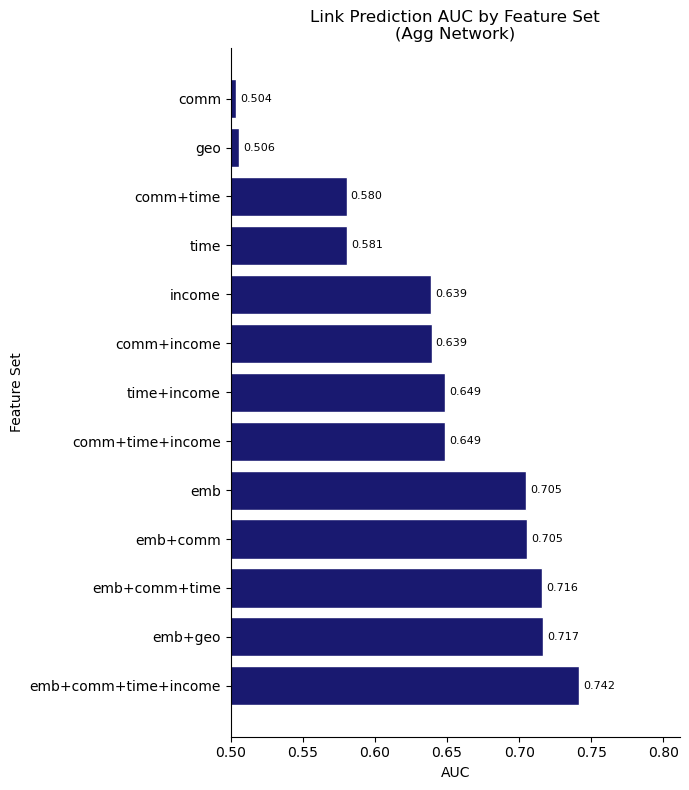

In [17]:
score_dir = "data/agg/tests/seed21"
score_files = glob.glob(os.path.join(score_dir, "score_*.txt"))

feature_scores = {}
for path in score_files:
    m = re.search(r"feats_([^-]+)-ct", os.path.basename(path))
    if m:
        feats = m.group(1).replace("_", "+")
        with open(path) as f:
            feature_scores[feats] = float(f.read().strip())

feature_scores = dict(sorted(feature_scores.items(), key=lambda x: x[1]))

labels = list(feature_scores.keys())
values = list(feature_scores.values())

fig, ax = plt.subplots(figsize=(7, 8))
bars = ax.barh(labels, values, color="midnightblue", edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.set_ylabel("Feature Set")
ax.set_xlabel("AUC")
ax.set_title("Link Prediction AUC by Feature Set\n(Agg Network)")
ax.set_xlim(0.5, max(values) + 0.07)
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("imgs/agg/link_pred_auc_seed21.png", dpi=150)
plt.show()


### Geographic Dependency Analysis (Tract + Category)

#1: ('Arts / Museum', 'Public Administration') | ks = 0.26351145413010274
#2: ('Public Administration', 'Arts / Museum') | ks = 0.26351145413010274
#3: ('Arts / Museum', 'City / Outdoors') | ks = 0.26283374317791863
#4: ('City / Outdoors', 'Arts / Museum') | ks = 0.26283374317791863
#5: ('Arts / Museum', 'College') | ks = 0.2508671925753674
#6: ('College', 'Arts / Museum') | ks = 0.2508671925753674
#7: ('Public Administration', 'City / Outdoors') | ks = 0.24713975647266267
#8: ('City / Outdoors', 'Public Administration') | ks = 0.24713975647266267
#9: ('School', 'City / Outdoors') | ks = 0.24544883580554233
#10: ('City / Outdoors', 'School') | ks = 0.24544883580554233
#11: ('School', 'Public Administration') | ks = 0.2392808511848699
#12: ('Public Administration', 'School') | ks = 0.2392808511848699


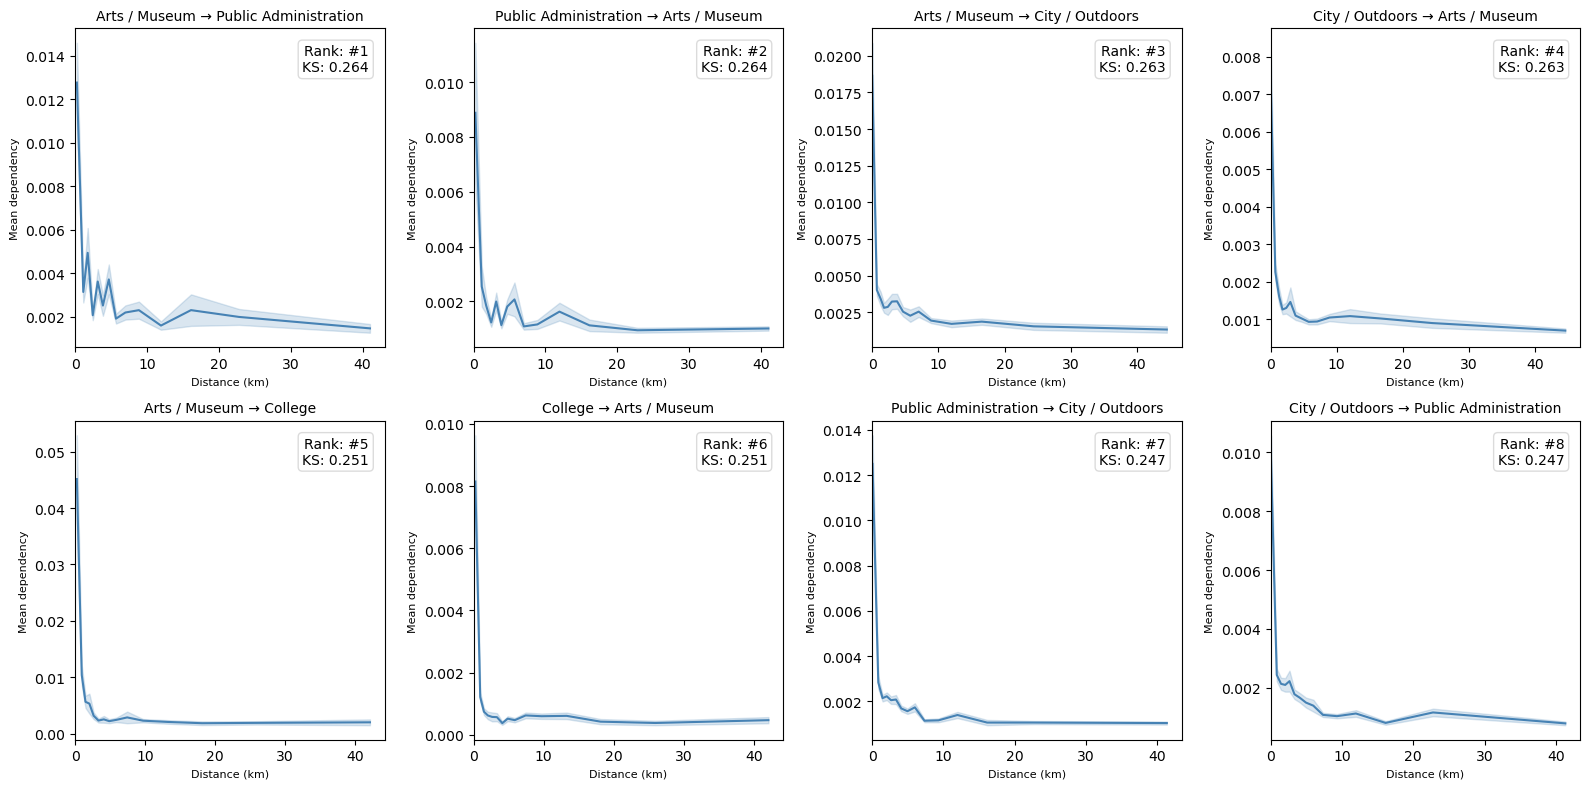

In [3]:
# dependency as a function of distance for each permutation

# collect (dist, dep) pairs per permutation
edge_pairs = defaultdict(list)
for u, v, data in G.edges(data=True):
    u_cat = u.split('||')[0]
    v_cat = v.split('||')[0]
    dist = data.get('dist_km')
    dep = data.get('dir_dep')
    if dist is not None and dep is not None:
        edge_pairs[(u_cat, v_cat)].append((dist, dep))

perm_to_data = {perm: edge_pairs[perm] for perm in perms}
perm_to_dist = {perm: [d for d, _ in vals] for perm, vals in perm_to_data.items()}

# --- rank by KS distance from overall distribution ---

all_dists = [d for dists in perm_to_dist.values() for d in dists]

ks_scores = {}
for perm, dists in perm_to_dist.items():
    if len(dists) < 30:
        continue
    stat, _ = ks_2samp(dists, all_dists)
    ks_scores[perm] = stat

top_perms = sorted(ks_scores, key=ks_scores.get, reverse=True)[:12]
for i, p in enumerate(top_perms, 1):
    print(f'#{i}: {p} | ks = {ks_scores.get(p)}')

# --- plot dep as a function of distance (binned mean ± SE) ---

N_BINS = 15
n_plots = len(top_perms[:8])
n_cols = 4
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, perm in enumerate(top_perms[:8]):
    ax = axes[i]
    data = perm_to_data[perm]
    if not data:
        continue
    dists = np.array([d for d, _ in data])
    deps  = np.array([d for _, d in data])

    bin_edges = np.percentile(dists, np.linspace(0, 100, N_BINS + 1))
    bin_idx = np.digitize(dists, bin_edges[1:-1])
    centers, means, ses = [], [], []
    for b in range(N_BINS):
        mask = bin_idx == b
        if mask.sum() < 3:
            continue
        centers.append(dists[mask].mean())
        means.append(deps[mask].mean())
        ses.append(deps[mask].std() / np.sqrt(mask.sum()))

    centers, means, ses = np.array(centers), np.array(means), np.array(ses)
    ax.plot(centers, means, color='steelblue', linewidth=1.5)
    ax.fill_between(centers, means - ses, means + ses, alpha=0.2, color='steelblue')

    rank_text = f"Rank: #{i+1}\nKS: {ks_scores[perm]:.3f}"
    ax.text(0.95, 0.95, rank_text,
            transform=ax.transAxes, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='lightgray'))

    ax.set_title(f"{perm[0]} → {perm[1]}", fontsize=10)
    ax.set_xlabel('Distance (km)', fontsize=8)
    ax.set_ylabel('Mean dependency', fontsize=8)
    ax.set_xlim(0)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

with open('data/agg/dir_dep/top_perms.pkl', 'wb') as f:
    pickle.dump(top_perms, f)

plt.tight_layout()
plt.savefig('imgs/agg/geo_cat_dep/dep_dist_distr.png', dpi=300)

In [4]:
# --- tract-level permutation dependency storage ---

# main loop
rows = []
for perm in tqdm(perms):
    s, t = perm
    for tract in tracts:
        nodes_in_tract = [n for n in G.nodes() if n.split('||')[1] == tract]
        target_node = next((n for n in nodes_in_tract if n.split('||')[0] == t), None)
        if target_node:
            # retrieve all incoming edges with the chosen source cat
            edges_to_take = [
                (u, v) for (u, v) in G.in_edges(target_node) if u.split('||')[0] == s
            ]
            # store
            avg_dep = np.mean([G.edges[u, v].get('dir_dep', 0.0) for (u, v) in edges_to_take])
            sum_dep = np.sum([G.edges[u, v].get('dir_dep', 0.0) for (u, v) in edges_to_take])
            rows.append(
                {'tract': tract, 'source_cat': s, 'target_cat': t, 'avg_dep': avg_dep, 'sum_dep': sum_dep}
            )
        else:
            continue

# convert to df and save
dep_df = pd.DataFrame(rows)
dep_df.to_parquet('data/agg/dir_dep/cat_dep_dir.parquet', index=False)

print(f"Saved {len(dep_df)} rows — {dep_df['tract'].nunique()} tracts, {dep_df[['target_cat','source_cat']].drop_duplicates().shape[0]} perms")

  0%|          | 0/380 [00:00<?, ?it/s]

c:\Users\User\anaconda3\envs\depnet\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\User\anaconda3\envs\depnet\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Saved 285475 rows — 1029 tracts, 380 perms


380 directed permutations | 1029 total tracts
 source_cat            target_cat  mean_dep  n_tracts
Agriculture       City / Outdoors  0.013514        98
Agriculture         Arts / Museum  0.012424        37
     School           Agriculture  0.011752        12
Agriculture              Shopping  0.011521       325
Agriculture              Industry  0.011379        95
Agriculture    Automotive Service  0.010845       214
Agriculture                Sports  0.010158       157
Agriculture                  Food  0.009696       417
Agriculture                School  0.008924        17
Agriculture               Service  0.008498       140
Agriculture               Grocery  0.008411       165
Agriculture                Office  0.008390       162
Agriculture  Neighborhood Service  0.008382        78
Agriculture          Coffee / Tea  0.007672       203
Agriculture Personal Care Service  0.007610       220


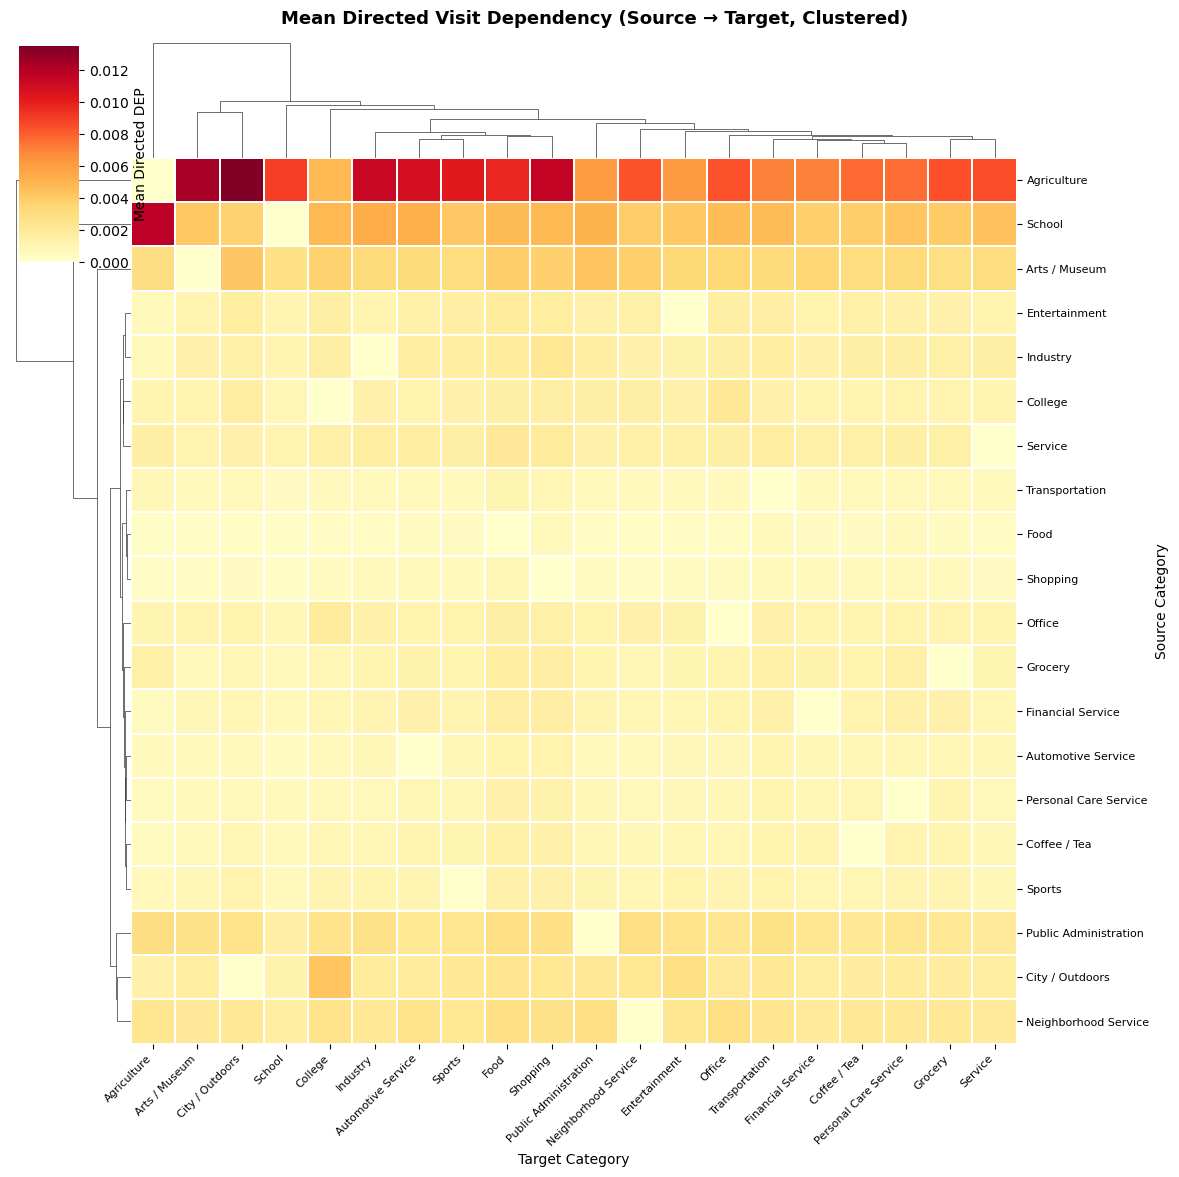

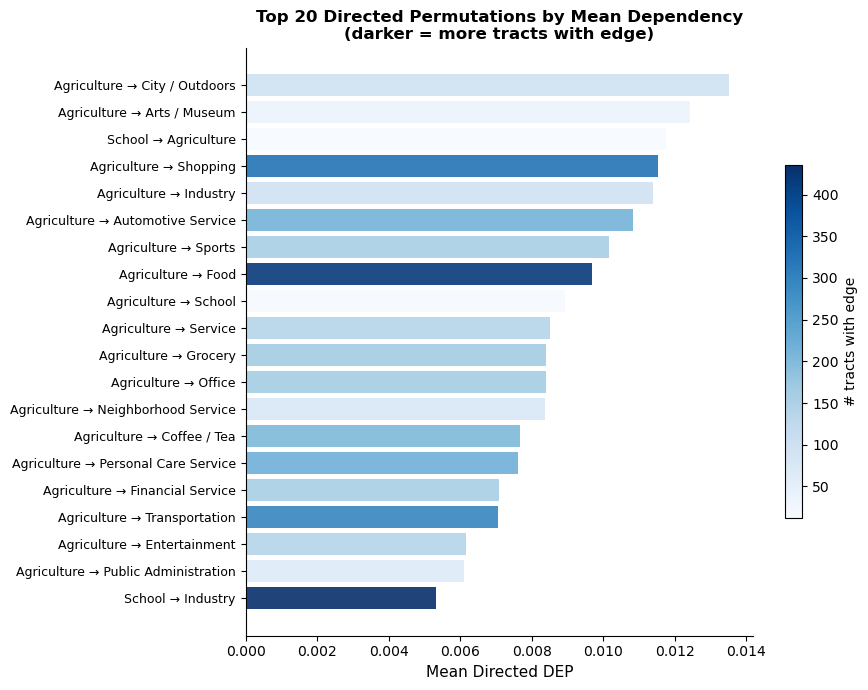

In [5]:
# -- heatmap + barchart: directed dependency analysis (AI) ---

# load if needed
if 'dep_df' not in globals():
    dep_df = pd.read_parquet('data/agg/dir_dep/cat_dep_dir.parquet')

# --- per-permutation aggregate stats (non-zero, non-NaN tracts only) ---
nonzero = dep_df[dep_df['avg_dep'].notna() & (dep_df['avg_dep'] > 0)]
perm_stats = (
    nonzero
    .groupby(['source_cat', 'target_cat'])['avg_dep']
    .agg(mean_dep='mean', n_tracts='count')
    .reset_index()
    .sort_values('mean_dep', ascending=False)
)

print(f"{len(perm_stats)} directed permutations | {dep_df['tract'].nunique()} total tracts")
print(perm_stats.head(15).to_string(index=False))

# --- directed matrix: rows = source, cols = target ---
all_cats = sorted(set(perm_stats['source_cat']) | set(perm_stats['target_cat']))
mat = pd.DataFrame(0.0, index=all_cats, columns=all_cats)
for _, row in perm_stats.iterrows():
    mat.loc[row['source_cat'], row['target_cat']] = row['mean_dep']

# === clustered heatmap (directed) ===
cg = sns.clustermap(
    mat, cmap='YlOrRd', figsize=(12, 12),
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Mean Directed DEP'},
    method='average', metric='euclidean',
    dendrogram_ratio=0.12
)
cg.ax_heatmap.set_xticklabels(cg.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=8)
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)
cg.ax_heatmap.set_xlabel('Target Category', fontsize=10)
cg.ax_heatmap.set_ylabel('Source Category', fontsize=10)
cg.figure.suptitle('Mean Directed Visit Dependency (Source → Target, Clustered)', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('imgs/agg/perm_dep_heatmap_clustered.png', dpi=300, bbox_inches='tight')
plt.show()

# === top 20 bar chart, colored by tract coverage ===
top20 = perm_stats.head(20).copy()
top20['label'] = top20['source_cat'] + ' → ' + top20['target_cat']

fig, ax = plt.subplots(figsize=(9, 7))
norm = plt.Normalize(top20['n_tracts'].min(), top20['n_tracts'].max())
colors = [plt.cm.Blues(norm(v)) for v in top20['n_tracts'].values[::-1]]
ax.barh(range(len(top20)), top20['mean_dep'].values[::-1], color=colors, alpha=0.9)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['label'].values[::-1], fontsize=9)
ax.set_xlabel('Mean Directed DEP', fontsize=11)
ax.set_title('Top 20 Directed Permutations by Mean Dependency\n(darker = more tracts with edge)', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='# tracts with edge', shrink=0.6)

plt.tight_layout()
plt.savefig('imgs/agg/dir_dep_top20.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# --- mapping setup and plotting function ---

# import data
stats = pd.read_parquet('data/agg/dir_dep/cat_dep_dir.parquet')
cbg_gdf = gpd.read_file('data/geo/tl_2025_25_bg.shp').to_crs('EPSG:4326')

# agg shapefile up to tract level
cbg_gdf['tract'] = cbg_gdf['GEOID'].str.slice(0, 11)
tract_gdf = cbg_gdf.dissolve(by='tract', aggfunc='first')
tract_gdf = tract_gdf.reset_index()

def map_dep(to_plot, map_vers='perm', perm_type=None, save_name='unnamed', rank=None):
    
    if map_vers == 'single':
        mapping_df = stats[stats['source_cat'].eq(to_plot) | stats['target_cat'].eq(to_plot)]
        mapping_df = mapping_df.groupby('tract')['avg_dep'].mean().reset_index()
        title_text = f"Average Visit Dependency of Permutations Involving {to_plot} by Census Tract"
    
    elif map_vers == 'perm':
        first, second = to_plot
        if perm_type == 'grouped':
            mapping_df = stats[stats['source_cat'].isin(first) & (stats['target_cat'].isin(second))]
            mapping_df = mapping_df.groupby('tract')['avg_dep'].mean().reset_index()
            title_text = f"Average Visit Dependency: {first} → {second} by Census Tract"
        else:
            filtered_df = stats[(stats['source_cat'] == first) & (stats['target_cat'] == second)]
            mapping_df = filtered_df[['tract', 'avg_dep']]
            title_text = f"Visit Dependency: {first} → {second} by Census Tract"

    merged_gdf = tract_gdf.merge(mapping_df, on='tract')

    fig, ax = plt.subplots(figsize=(10, 8))

    merged_gdf.plot(
        column='avg_dep', 
        cmap='Reds', 
        linewidth=0.4, 
        ax=ax, 
        edgecolor=".4",
        legend=True
    )

    if rank is not None:
        ax.text(
            0.98, 0.97, f"Rank #{rank}",
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8)
        )
    
    plt.xticks(rotation=90)
    ax.set_title(title_text, fontsize=14, fontweight='bold', pad=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(
        f'imgs/agg/geo_cat_dep/maps/gcv_{save_name}.png', 
        dpi=500,
        bbox_inches='tight',
    )
    plt.close(fig)

    print(f'{to_plot} plotted and saved successfully.')

In [8]:
# --- map the same ones found from KS test ---

# load stuff back in if needed

if 'stats' not in globals() and 'stats' not in locals() or stats is None or \
   'G' not in globals() and 'G' not in locals() or G is None:
    
    print('df or network not loaded or is None. Loading in.')
    stats = pd.read_parquet('data/agg/cat_dep_dir.parquet')
    
    with open(fpath, 'rb') as f:
        G = pickle.load(f)

# feed the function

if not top_perms:
    with open('data/agg/geo_cat_dep/top_perms.pkl', 'rb') as f:
        top_perms = pickle.load(f)

topN = top_perms[:8]

for i, perm in enumerate(topN, 1):
    elem1, elem2 = perm[0].split(' ')[0].lower(), perm[1].split(' ')[0].lower()
    map_dep(perm, save_name=f"{elem1}_{elem2}", rank=i)

('Arts / Museum', 'Public Administration') plotted and saved successfully.
('Public Administration', 'Arts / Museum') plotted and saved successfully.
('Arts / Museum', 'City / Outdoors') plotted and saved successfully.
('City / Outdoors', 'Arts / Museum') plotted and saved successfully.
('Arts / Museum', 'College') plotted and saved successfully.
('College', 'Arts / Museum') plotted and saved successfully.
('Public Administration', 'City / Outdoors') plotted and saved successfully.
('City / Outdoors', 'Public Administration') plotted and saved successfully.


Subdivision Version

In [ ]:
# === county subdivision setup ===

cousub_gdf = gpd.read_file('data/geo/cousub/tl_2025_25_cousub.shp').to_crs('EPSG:4326')
cousub_gdf = cousub_gdf[['GEOID', 'NAME', 'geometry']].rename(columns={'GEOID': 'cousub'})
stats = pd.read_parquet('data/agg/cat_dep_long.parquet')

# spatial join: assign each tract centroid to its county subdivision
tract_centroids = tract_gdf[['tract', 'geometry']].copy()
tract_centroids['geometry'] = tract_centroids.geometry.centroid

tract_cousub = gpd.sjoin(
    tract_centroids,
    cousub_gdf[['cousub', 'geometry']],
    how='left',
    predicate='within'
)[['tract', 'cousub']]

n_unmapped = tract_cousub['cousub'].isna().sum()
if n_unmapped > 0:
    print(f"Warning: {n_unmapped} tracts did not fall within any county subdivision")

# aggregate dep from tract → cousub (mean across tracts)
cousub_stats = (
    stats
    .merge(tract_cousub, on='tract')
    .groupby(['cousub', 'cat1', 'cat2'])['dep']
    .mean()
    .reset_index()
)

print(f"County subdivisions: {cousub_stats['cousub'].nunique()}")
print(f"Combos: {cousub_stats[['cat1','cat2']].drop_duplicates().shape[0]}")


def map_dep_cousub(to_plot, map_vers='combo', combo_type=None, save_name='unnamed'):

    if map_vers == 'single':
        mapping_df = cousub_stats[cousub_stats['cat1'].eq(to_plot) | cousub_stats['cat2'].eq(to_plot)]
        mapping_df = mapping_df.groupby('cousub')['dep'].mean().reset_index()
        title_text = f"Average Visit Dependency Involving {to_plot} by County Subdivision"

    elif map_vers == 'combo':
        first, second = to_plot
        if combo_type == 'grouped':
            mapping_df = cousub_stats[cousub_stats['cat1'].isin(first) & cousub_stats['cat2'].isin(second)]
            mapping_df = mapping_df.groupby('cousub')['dep'].mean().reset_index()
            title_text = f"Average Visit Dependency: {first} → {second} by County Subdivision"
        else:
            filtered_df = cousub_stats[(cousub_stats['cat1'] == first) & (cousub_stats['cat2'] == second)]
            mapping_df = filtered_df[['cousub', 'dep']]
            title_text = f"Visit Dependency: {first} → {second} by County Subdivision"

    merged_gdf = cousub_gdf.merge(mapping_df, on='cousub')

    fig, ax = plt.subplots(figsize=(10, 8))
    merged_gdf.plot(
        column='dep',
        cmap='Reds',
        linewidth=0.4,
        ax=ax,
        edgecolor='.4',
        legend=True,
    )
    ax.set_title(title_text, fontsize=14, fontweight='bold', pad=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(
        f'imgs/geo_cat_variance/cousub/gcv_{save_name}_cousub.png',
        dpi=300,
        bbox_inches='tight',
    )
    plt.close(fig)
    print(f'{to_plot} plotted and saved successfully.')

County subdivisions: 147
Combos: 190


C:\Users\User\AppData\Local\Temp\ipykernel_9928\3643592192.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  tract_centroids['geometry'] = tract_centroids.geometry.centroid


In [ ]:
# === county subdivision analysis ===

w_cousub = Queen.from_dataframe(cousub_gdf.set_index('cousub'))
w_cousub.transform = 'r'

measures_cousub = {}
min_cousub = 30

for c in combos:
    filtered_df = cousub_stats[(cousub_stats['cat1'] == c[0]) & (cousub_stats['cat2'] == c[1])]
    observed = filtered_df[filtered_df['dep'] > 0]
    if len(observed) < min_cousub:
        continue

    dep_series = cousub_gdf['cousub'].map(observed.set_index('cousub')['dep']).fillna(0)
    mi = esda.Moran(dep_series, w_cousub)
    if mi.p_sim < 0.05:
        measures_cousub[c] = mi.I

print(f"Combos with significant spatial autocorrelation: {len(measures_cousub)}")

top10_cousub = sorted(measures_cousub.items(), key=lambda item: item[1], reverse=True)[:10]
for k, v in top10_cousub:
    print(f"{k}: {v:.4f}")

for c in top10_cousub:
    combo = c[0]
    elem1, elem2 = combo[0].split(' ')[0].lower(), combo[1].split(' ')[0].lower()
    map_dep_cousub(combo, save_name=f"{elem1}_{elem2}")